# Real World Fine-tuning with APG

In [1]:
%load_ext autoreload
%autoreload 2

## Initialization

In [2]:
import os

xla_flags = os.environ.get("XLA_FLAGS", "")
xla_flags += " --xla_gpu_triton_gemm_any=True"
os.environ["XLA_FLAGS"] = xla_flags
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["MUJOCO_EGL_DEVICE_ID"] = "2"
os.environ["MUJOCO_GL"] = "egl"
# os.environ['MUJOCO_GL'] = 'osmesa'
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ['JAX_LOG_COMPILES'] = '0'

In [3]:
import functools
import json
from datetime import datetime

# --- JAX Configuration (MUST be done before other JAX imports) ---
import jax
from jax import config

# Use 64-bit precision (Must be set before backend initialization)
config.update("jax_enable_x64", True)
config.update("jax_default_matmul_precision", "high")

# Other JAX configs
config.update("jax_debug_nans", False)

# Compilation cache configuration
cache_path = "/data/jit_cache"
if not os.path.exists(cache_path):
    os.makedirs(cache_path)
    print(f"Created JAX compilation cache directory at {cache_path}")

config.update("jax_compilation_cache_dir", cache_path)
config.update("jax_persistent_cache_min_entry_size_bytes", -1)
config.update("jax_persistent_cache_min_compile_time_secs", 1)
# -----------------------------------------------------------------

# Now import libraries that depend on JAX
import jax.numpy as jp
import matplotlib.pyplot as plt
import mediapy as media
import mujoco
import numpy as np
import wandb

from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from apg_alg.algorithm import apg
from apg_alg.networks import apg_networks

from etils import epath
from flax.training import orbax_utils
from IPython.display import clear_output, display
from orbax import checkpoint as ocp

from mujoco_playground import locomotion, wrapper
from mujoco_playground.config import locomotion_params

print("JAX configured. x64 enabled:", config.read("jax_enable_x64"))

Warp DeprecationWarning: The namespace `warp.context` will soon be removed from the public API. It can still be accessed from `warp._src.context` but might be changed or removed without notice.
Warp DeprecationWarning: The symbol `warp.context.Module` will soon be removed from the public API. Use `warp.Module` instead.
Warp DeprecationWarning: The symbol `warp.context.get_module` will soon be removed from the public API. Use `warp.get_module` instead.
Warp DeprecationWarning: The namespace `warp.math` will soon be removed from the public API. It can still be accessed from `warp._src.math` but might be changed or removed without notice.
JAX configured. x64 enabled: True


In [4]:
mjx_env_name = "Go2Joystick2"
mj_env_name = "Go2JoystickMujoco"
mjx_env_cfg = locomotion.get_default_config(mjx_env_name)
mj_env_cfg = locomotion.get_default_config(mj_env_name)
randomizer = locomotion.get_domain_randomizer(mjx_env_name)
apg_params = locomotion_params.brax_apg_config(mjx_env_name)

## Test mjx env and mj env

### Twin Model Template

`JoystickGo2Mujoco` exposes a `mujoco_model` config block for permanent twin-model overrides.
Use the helper below as a starting point, then copy the fields you actually want to modify.


In [5]:
from mujoco_playground._src.locomotion.go2.JoystickGo2Mujoco import make_mujoco_model_template

mj_twin_template = make_mujoco_model_template()
mj_twin_template


body_inertia: {}
body_mass: {}
geom_friction: {}
geom_solimp: {}
geom_solref: {}
joint_armature: {}
joint_damping: {}
joint_frictionloss: {}
xml_path: /data/mujoco_playground/mujoco_playground/_src/locomotion/go2/xmls/scene.xml

### MJX vs MuJoCo Consistency Check

This compares `Go2Joystick2` and `Go2JoystickMujoco` under the same RNG seed and the same open-loop action sequence.
The two backends will not be numerically identical forever, but with the default models they should stay reasonably close over a short horizon.


In [6]:
def compare_mjx_and_mujoco(env_name_mjx='Go2Joystick2', env_name_mj='Go2JoystickMujoco', seed=0, horizon=10, action_scale=0.0, use_mjx_xml_for_mujoco=True):
    from mujoco_playground._src.locomotion.go2 import go2_constants as consts

    mjx_env_cfg = locomotion.get_default_config(env_name_mjx)
    mj_env_cfg = locomotion.get_default_config(env_name_mj)
    mjx_env_cfg.disturbance.enable = False
    mj_env_cfg.disturbance.enable = False
    if use_mjx_xml_for_mujoco:
        mj_env_cfg.mujoco_model.xml_path = consts.MJX_XML_SENSOR_PATH.as_posix()

    mjx_env = locomotion.load(env_name_mjx, config=mjx_env_cfg)
    mj_env = locomotion.load(env_name_mj, config=mj_env_cfg)

    rng = jax.random.PRNGKey(seed)
    state_mjx = mjx_env.reset(rng)
    state_mj = mj_env.reset(rng)

    rows = []

    def collect(tag, s_mjx, s_mj):
        rows.append({
            'tag': tag,
            'obs_linf': float(jp.max(jp.abs(s_mjx.obs['state'] - s_mj.obs['state']))),
            'qpos_linf': float(jp.max(jp.abs(s_mjx.data.qpos - s_mj.data.qpos))),
            'qvel_linf': float(jp.max(jp.abs(s_mjx.data.qvel - s_mj.data.qvel))),
            'reward_abs_diff': float(jp.abs(s_mjx.reward - s_mj.reward)),
            'done_abs_diff': float(jp.abs(s_mjx.done - s_mj.done)),
        })

    collect('reset', state_mjx, state_mj)

    action_rng = jax.random.PRNGKey(seed + 1)
    for step in range(horizon):
        if action_scale == 0.0:
            action = jp.zeros(mjx_env.action_size)
        else:
            action_rng, subkey = jax.random.split(action_rng)
            action = jax.random.uniform(
                subkey,
                (mjx_env.action_size,),
                minval=-action_scale,
                maxval=action_scale,
            )
        state_mjx = mjx_env.step(state_mjx, action)
        state_mj = mj_env.step(state_mj, action)
        collect(f'step_{step+1}', state_mjx, state_mj)

    return rows

consistency_rows = compare_mjx_and_mujoco(horizon=5, action_scale=0.0, use_mjx_xml_for_mujoco=True)
consistency_rows


[{'tag': 'reset',
  'obs_linf': 0.0,
  'qpos_linf': 0.018372500302558048,
  'qvel_linf': 0.0,
  'reward_abs_diff': 0.0,
  'done_abs_diff': 0.0},
 {'tag': 'step_1',
  'obs_linf': 0.0963261465922102,
  'qpos_linf': 0.03037707319236249,
  'qvel_linf': 1.9265229318442039,
  'reward_abs_diff': 0.01887339632631685,
  'done_abs_diff': 0.0},
 {'tag': 'step_2',
  'obs_linf': 0.05241680983968822,
  'qpos_linf': 0.052416809839688216,
  'qvel_linf': 0.3660212469798525,
  'reward_abs_diff': 0.018497373267452114,
  'done_abs_diff': 0.0},
 {'tag': 'step_3',
  'obs_linf': 0.05235589295056431,
  'qpos_linf': 0.05235589295056431,
  'qvel_linf': 0.49805622711774855,
  'reward_abs_diff': 0.016520222381512913,
  'done_abs_diff': 0.0},
 {'tag': 'step_4',
  'obs_linf': 0.04627710393468676,
  'qpos_linf': 0.04627710393468676,
  'qvel_linf': 0.5917675129021251,
  'reward_abs_diff': 0.014432236130428107,
  'done_abs_diff': 0.0},
 {'tag': 'step_5',
  'obs_linf': 0.039020215763655886,
  'qpos_linf': 0.03902021576

### Consistency Summary and Plots

Turn `consistency_rows` into a table and plot the backend mismatch over time.


In [7]:
import pandas as pd

consistency_df = pd.DataFrame(consistency_rows)
consistency_df


,tag,obs_linf,qpos_linf,qvel_linf,reward_abs_diff,done_abs_diff
0,reset,0.000000,0.018373,0.000000,0.000000,0.0
1,step_1,0.096326,0.030377,1.926523,0.018873,0.0
2,step_2,0.052417,0.052417,0.366021,0.018497,0.0
3,step_3,0.052356,0.052356,0.498056,0.016520,0.0
4,step_4,0.046277,0.046277,0.591768,0.014432,0.0
5,step_5,0.039020,0.039020,0.586576,0.014210,0.0


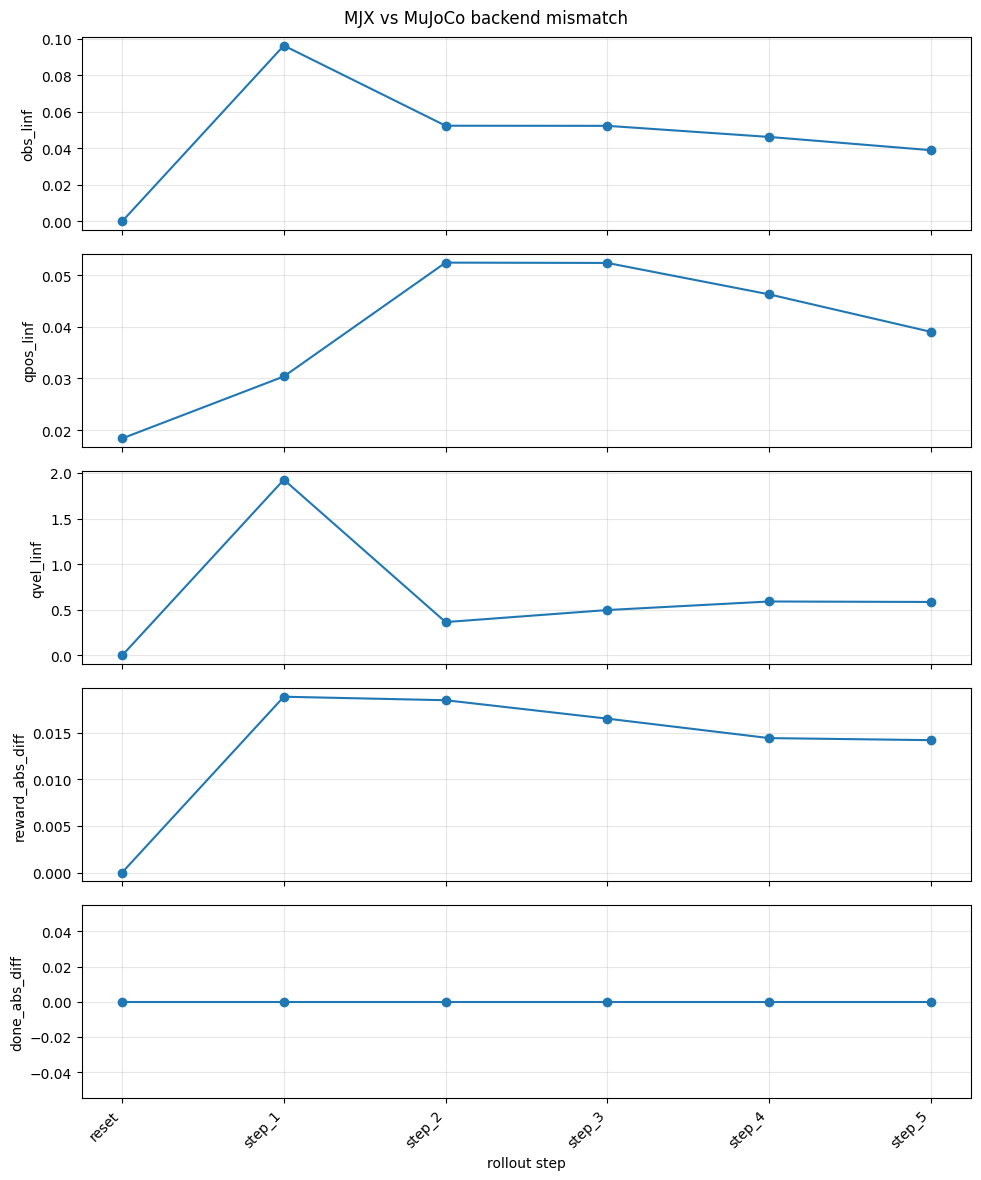

In [8]:
plot_cols = ['obs_linf', 'qpos_linf', 'qvel_linf', 'reward_abs_diff', 'done_abs_diff']
fig, axes = plt.subplots(len(plot_cols), 1, figsize=(10, 12), sharex=True)

x = np.arange(len(consistency_df))
labels = consistency_df['tag'].tolist()

for ax, col in zip(axes, plot_cols):
    ax.plot(x, consistency_df[col].to_numpy(), marker="o")
    ax.set_ylabel(col)
    ax.grid(True, alpha=0.3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(labels, rotation=45, ha="right")
axes[-1].set_xlabel("rollout step")
fig.suptitle("MJX vs MuJoCo backend mismatch")
fig.tight_layout()
plt.show()


In [9]:
summary = consistency_df[plot_cols].agg(["max", "mean", "std"])
summary


,obs_linf,qpos_linf,qvel_linf,reward_abs_diff,done_abs_diff
max,0.096326,0.052417,1.926523,0.018873,0.0
mean,0.047733,0.039803,0.661491,0.013755,0.0
std,0.030858,0.013471,0.657627,0.007017,0.0


## State Alignment Verification

This section verifies State Alignment with a frozen residual policy from `go2_constants.RESIDUAL_PATH`.

The aligned state uses the native MuJoCo transition for the forward value, while the gradient still flows through the MJX transition and is scaled by `alpha`. When the MuJoCo backend represents the mismatched real world, the downstream Jacobian is evaluated at that MuJoCo forward state, which is the intended behavior for state alignment.


In [7]:
from mujoco_playground._src.locomotion.go2 import go2_constants as consts
from mujoco_playground._src.locomotion.go2 import managers as manager_lib
from mujoco_playground._src.locomotion.go2.managers import state_alignment_manager as state_alignment_lib
from mujoco_playground._src.locomotion.go2.JoystickGo2 import JoystickGo2
from mujoco_playground._src.locomotion.go2.JoystickGo2Mujoco import (
    JoystickGo2Mujoco,
    default_config as mujoco_default_config,
)
from mujoco_playground._src.locomotion.go2.configs import joystick_config
import pandas as pd


def make_alignment_configs(use_mjx_xml_for_mujoco=True):
    mjx_cfg = joystick_config.default_config()
    mjx_cfg.anchor.path = None
    mjx_cfg.disturbance.enable = False
    mjx_cfg.assistive_wrench.enable = False

    mj_cfg = mujoco_default_config()
    mj_cfg.anchor.path = None
    mj_cfg.disturbance.enable = False
    mj_cfg.assistive_wrench.enable = False
    if use_mjx_xml_for_mujoco:
        mj_cfg.mujoco_model.xml_path = consts.MJX_XML_SENSOR_PATH.as_posix()

    return mjx_cfg, mj_cfg


def verification_loss_fn(env, data):
    base_height = data.xpos[env.base_id, 2]
    foot_term = 0.01 * jp.sum(jp.square(data.site_xpos[env._feet_site_id]))
    return base_height + foot_term


In [8]:
rollout_horizon = 8

mjx_cfg_align, mj_cfg_align = make_alignment_configs(use_mjx_xml_for_mujoco=True)

mjx_env_align = JoystickGo2(config=mjx_cfg_align)
mj_env_align = JoystickGo2Mujoco(config=mj_cfg_align)
state_alignment_manager = manager_lib.StateAlignmentManager(mjx_env_align, mj_env_align)

residual_policy = state_alignment_lib.load_residual_inference_fn(consts.RESIDUAL_PATH)

rng = jax.random.PRNGKey(0)
state_align_mjx = mjx_env_align.reset(rng)
state_align_mj = mj_env_align.reset(rng)

mjx_step, align_step = state_alignment_manager.make_step_fns(
    initial_mjx_state=state_align_mjx,
    initial_native_state=state_align_mj,
    policy_fn=residual_policy,
    horizon=rollout_horizon,
    loss_fn=verification_loss_fn,
)

policy_rng = jax.random.PRNGKey(123)
test_action, test_aux = residual_policy(state_align_mjx.obs, policy_rng)
test_action.shape

eta0 = jp.array(1.0, dtype=state_align_mjx.data.qpos.dtype)
alpha1 = jp.array(1.0, dtype=state_align_mjx.data.qpos.dtype)
alpha0 = jp.array(0.0, dtype=state_align_mjx.data.qpos.dtype)

metrics_mjx = mjx_step(eta0)
metrics_alpha1 = align_step(eta0, alpha1)
metrics_alpha0 = align_step(eta0, alpha0)

grad_mjx = jax.grad(lambda eta: mjx_step(eta)["loss"])(eta0)
grad_alpha1 = jax.grad(lambda eta: align_step(eta, alpha1)["loss"])(eta0)
grad_alpha0 = jax.grad(lambda eta: align_step(eta, alpha0)["loss"])(eta0)

verification_df = pd.DataFrame([
    {"case": "mjx_only", **{k: float(v) for k, v in metrics_mjx.items()}, "grad_dloss_deta": float(grad_mjx)},
    {"case": "align_alpha_1", **{k: float(v) for k, v in metrics_alpha1.items()}, "grad_dloss_deta": float(grad_alpha1)},
    {"case": "align_alpha_0", **{k: float(v) for k, v in metrics_alpha0.items()}, "grad_dloss_deta": float(grad_alpha0)},
])
verification_df["grad_abs_diff_vs_mjx"] = np.abs(verification_df["grad_dloss_deta"] - float(grad_mjx))

print("Residual policy path:", consts.RESIDUAL_PATH)
print("Rollout horizon:", rollout_horizon)
verification_df


Residual policy path: /data/mujoco_playground/mujoco_playground/experimental/learning/checkpoints/Go2Joystick2-20260403-070849-apg/params.pkl
Rollout horizon: 8


,case,final_done,loss,mean_ctrl_norm,mean_qpos_gap,mean_qvel_gap,reward_sum,grad_dloss_deta,grad_abs_diff_vs_mjx
0,mjx_only,0.0,2.161342,4.178607,0.109836,4.004434,0.216771,0.077656,0.000000
1,align_alpha_1,0.0,2.134077,4.172679,0.030842,2.140115,0.093238,0.121157,0.043500
2,align_alpha_0,0.0,2.134077,4.172679,0.030842,2.140115,0.093238,0.000000,0.077656
